### IMPORTANDO E CONSOLIDANDO AS BASES

In [150]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [151]:
caminho = 'BASE DE DADOS PEDE 2024 - DATATHON.xlsx'

In [152]:
df_22 = pd.read_excel(caminho, sheet_name='PEDE2022')
df_23 = pd.read_excel(caminho, sheet_name='PEDE2023')
df_24 = pd.read_excel(caminho, sheet_name='PEDE2024')

In [153]:
df_22['ano'] = 2022
df_23['ano'] = 2023
df_24['ano'] = 2024

In [154]:
df = pd.concat([df_22, df_23, df_24], ignore_index=True)

In [155]:
colunas_base = ['Defasagem', 'Fase', 'Gênero', 'IAA', 'IAN', 'IDA', 'IEG', 'INDE', 'IPP', 'IPS', 'IPV', 'Nome', 'Pedra', 'RA', 'Ano nasc', 'Ano ingresso', 'Fase ideal', 'ano']

In [156]:
df = df[colunas_base]
df.head()

,Defasagem,Fase,Gênero,IAA,IAN,IDA,IEG,INDE,IPP,IPS,IPV,Nome,Pedra,RA,Ano nasc,Ano ingresso,Fase ideal,ano
0,-1,7,Feminino,8.3,5.0,4.0,4.1,5.783,8.174,5.6,7.278,Aluno-1,Quartzo,RA-1,2003,2016,Fase 8 (Universitários),2022
1,0,7,Feminino,8.8,10.0,6.8,5.2,7.055,7.894,6.3,6.778,Aluno-2,Ametista,RA-2,2005,2017,Fase 7 (3º EM),2022
2,0,7,Feminino,0.0,10.0,5.6,7.9,6.591,8.198,5.6,7.556,Aluno-3,Ágata,RA-3,2005,2016,Fase 7 (3º EM),2022
3,0,7,Masculino,8.8,10.0,5.0,4.5,5.951,5.554,5.6,5.278,Aluno-4,Quartzo,RA-4,2005,2017,Fase 7 (3º EM),2022
4,0,7,Feminino,7.9,10.0,5.2,8.6,7.427,8.392,5.6,7.389,Aluno-5,Ametista,RA-5,2005,2016,Fase 7 (3º EM),2022


In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2845 entries, 0 to 2844
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Defasagem     2845 non-null   int64  
 1   Fase          2845 non-null   object 
 2   Gênero        2845 non-null   object 
 3   IAA           2845 non-null   float64
 4   IAN           2845 non-null   float64
 5   IDA           2845 non-null   float64
 6   IEG           2845 non-null   float64
 7   INDE          2845 non-null   float64
 8   IPP           2845 non-null   float64
 9   IPS           2845 non-null   float64
 10  IPV           2845 non-null   float64
 11  Nome          2845 non-null   object 
 12  Pedra         2845 non-null   object 
 13  RA            2845 non-null   object 
 14  Ano nasc      2845 non-null   int64  
 15  Ano ingresso  2845 non-null   int64  
 16  Fase ideal    2845 non-null   object 
 17  ano           2845 non-null   int64  
dtypes: float64(8), int64(4), obj

In [158]:
df.isnull().sum()

Defasagem       0
Fase            0
Gênero          0
IAA             0
IAN             0
IDA             0
IEG             0
INDE            0
IPP             0
IPS             0
IPV             0
Nome            0
Pedra           0
RA              0
Ano nasc        0
Ano ingresso    0
Fase ideal      0
ano             0
dtype: int64

In [159]:
# salva df
df.to_csv('PEDE_CONSOLIDADO.csv', index=False)

### AVALIAÇÃO DO VOLUME DE DADOS

In [120]:
#conta quantos alunos aparecem nos 3 anos consecutivos, ou apenas em 2 ou 1 dos anos e conta os valores
contagem_anos = df.groupby('RA')['ano'].count().value_counts()
print(contagem_anos)

ano
1    761
3    434
2    391
Name: count, dtype: int64


In [121]:
# mesma contagem acima, mas sem agrupar a contagem
contagem_anos = df.groupby('RA')['ano'].count()
contagem_anos

RA
RA-1       1
RA-10      1
RA-100     1
RA-1000    2
RA-1001    2
          ..
RA-995     2
RA-996     1
RA-997     1
RA-998     1
RA-999     1
Name: ano, Length: 1586, dtype: int64

### SEPARAÇÃO DAS BASES

Irei avaliar as bases em duas estratégias: 1-alunos que constam em 2 ou 3 anos da base; 2- alunos que constam nos 3 anos da base

In [122]:
# ==========================================
# ESTRATÉGIA 1: Mantem alunos com 2 ou 3 anos 
# ==========================================

# Pega apenas os RAs que aparecem 2 ou 3 vezes
alunos_validos = contagem_anos[contagem_anos >= 2].index

# Filtra o df apenas para esses alunos
df_base1 = df[df['RA'].isin(alunos_validos)].copy()

In [123]:
# ==========================================
# ESTRATÉGIA 2: Mantem APENAS alunos com 3 anos 
# ==========================================

alunos_3_anos = contagem_anos[contagem_anos == 3].index

df_base2_temp = df[df['RA'].isin(alunos_3_anos)].copy()

### PREPARAÇÃO DAS BASES PARA O MODELO

In [124]:
# Indicadores que serão utilizados no modelos (Sem o IAN - devido ser metrica redundante da defasagem, q será usada no target)
indicadores = ['Defasagem', 'IAA', 'IDA', 'IEG', 'INDE', 'IPP', 'IPS', 'IPV']

#### BASE ESTRATEGIA 1

In [125]:
# Organiza o df (estrategia 1) por ano - para que o shift pegue o dado na ordem cronologica correta
df_base1 = df_base1.sort_values(by=['RA', 'ano'])

#pega os indicadores do ano anterior do aluno e insere na mesma linha em outra coluna
for ind in indicadores:
    df_base1[f'{ind}_ANT_1'] = df_base1.groupby('RA')[ind].shift(1)

In [126]:
df_base1.head()

,Defasagem,Fase,Gênero,IAA,IAN,IDA,IEG,INDE,IPP,IPS,...,Fase ideal,ano,Defasagem_ANT_1,IAA_ANT_1,IDA_ANT_1,IEG_ANT_1,INDE_ANT_1,IPP_ANT_1,IPS_ANT_1,IPV_ANT_1
860,0,ALFA,Feminino,8.500,10.0,7.00,9.400000,7.916200,6.250000,3.77,...,ALFA (1° e 2° ano),2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1791,0,1,Feminino,9.002,10.0,7.75,9.545455,8.364791,8.125000,6.26,...,Fase 1 (3° e 4° ano),2024,0.0,8.5,7.0,9.4,7.9162,6.25,3.77,8.92
861,-1,ALFA,Feminino,9.000,5.0,7.80,9.100000,8.116200,7.500000,7.52,...,Fase 1 (3° e 4° ano),2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1792,-1,1,Feminino,7.502,5.0,7.75,9.347826,7.796432,7.916667,7.51,...,Fase 2 (5° e 6° ano),2024,-1.0,9.0,7.8,9.1,8.1162,7.50,7.52,9.17
862,-1,ALFA,Feminino,9.000,5.0,7.00,9.700000,7.901200,6.250000,7.52,...,Fase 1 (3° e 4° ano),2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [127]:
#cria uma coluna para avaliar se os alunos que tem apenas 2 anos na base, são sequenciais ou pulam de 22 para 24
df_base1['delta_tempo'] = df_base1['ano'] - df_base1.groupby('RA')['ano'].shift(1)
df_base1.head()

,Defasagem,Fase,Gênero,IAA,IAN,IDA,IEG,INDE,IPP,IPS,...,ano,Defasagem_ANT_1,IAA_ANT_1,IDA_ANT_1,IEG_ANT_1,INDE_ANT_1,IPP_ANT_1,IPS_ANT_1,IPV_ANT_1,delta_tempo
860,0,ALFA,Feminino,8.500,10.0,7.00,9.400000,7.916200,6.250000,3.77,...,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1791,0,1,Feminino,9.002,10.0,7.75,9.545455,8.364791,8.125000,6.26,...,2024,0.0,8.5,7.0,9.4,7.9162,6.25,3.77,8.92,1.0
861,-1,ALFA,Feminino,9.000,5.0,7.80,9.100000,8.116200,7.500000,7.52,...,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1792,-1,1,Feminino,7.502,5.0,7.75,9.347826,7.796432,7.916667,7.51,...,2024,-1.0,9.0,7.8,9.1,8.1162,7.50,7.52,9.17,1.0
862,-1,ALFA,Feminino,9.000,5.0,7.00,9.700000,7.901200,6.250000,7.52,...,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [128]:
# contagem para avaliar quantos alunos pulam de 22 p 24
df_base1['delta_tempo'].value_counts()

delta_tempo
1.0    1248
2.0      11
Name: count, dtype: int64

In [129]:
# remove linhas onde não há histórico para comparar e que há salto no intervalor de comparação (22-24)
df_treino_base1 = df_base1.dropna(subset=['INDE_ANT_1'])
df_treino_base1 = df_treino_base1[df_treino_base1['delta_tempo'] == 1]
df_treino_base1.head()

,Defasagem,Fase,Gênero,IAA,IAN,IDA,IEG,INDE,IPP,IPS,...,ano,Defasagem_ANT_1,IAA_ANT_1,IDA_ANT_1,IEG_ANT_1,INDE_ANT_1,IPP_ANT_1,IPS_ANT_1,IPV_ANT_1,delta_tempo
1791,0,1,Feminino,9.002,10.0,7.75,9.545455,8.364791,8.125000,6.26,...,2024,0.0,8.5,7.0,9.4,7.9162,6.250,3.77,8.92,1.0
1792,-1,1,Feminino,7.502,5.0,7.75,9.347826,7.796432,7.916667,7.51,...,2024,-1.0,9.0,7.8,9.1,8.1162,7.500,7.52,9.17,1.0
1793,-1,ALFA,Feminino,9.002,5.0,9.25,7.833333,7.967867,7.500000,7.51,...,2024,-1.0,9.0,7.0,9.7,7.9012,6.250,7.52,8.92,1.0
1794,-1,ALFA,Masculino,8.002,5.0,8.25,8.694444,7.627589,6.875000,7.51,...,2024,0.0,9.0,4.0,8.5,7.6522,7.500,7.52,8.75,1.0
1795,-1,ALFA,Feminino,9.502,5.0,7.50,9.250000,7.801200,7.500000,7.51,...,2024,0.0,9.0,7.9,9.6,8.3137,6.875,7.52,7.42,1.0


In [130]:
# Define a Target BINARIA: Se o INDE caiu ou a DEFASAGEM aumentou, então 'risco', se não, 'sem risco'
def alvo_base1(row):
    if pd.isnull(row['INDE_ANT_1']): return np.nan
    queda_inde = row['INDE'] < row['INDE_ANT_1']
    piorou_defasagem = row['Defasagem'] < row['Defasagem_ANT_1']
    return 1 if (queda_inde or piorou_defasagem) else 0

df_treino_base1['TARGET'] = df_treino_base1.apply(alvo_base1, axis=1)

In [131]:
df_treino_base1.head()

,Defasagem,Fase,Gênero,IAA,IAN,IDA,IEG,INDE,IPP,IPS,...,Defasagem_ANT_1,IAA_ANT_1,IDA_ANT_1,IEG_ANT_1,INDE_ANT_1,IPP_ANT_1,IPS_ANT_1,IPV_ANT_1,delta_tempo,TARGET
1791,0,1,Feminino,9.002,10.0,7.75,9.545455,8.364791,8.125000,6.26,...,0.0,8.5,7.0,9.4,7.9162,6.250,3.77,8.92,1.0,0
1792,-1,1,Feminino,7.502,5.0,7.75,9.347826,7.796432,7.916667,7.51,...,-1.0,9.0,7.8,9.1,8.1162,7.500,7.52,9.17,1.0,1
1793,-1,ALFA,Feminino,9.002,5.0,9.25,7.833333,7.967867,7.500000,7.51,...,-1.0,9.0,7.0,9.7,7.9012,6.250,7.52,8.92,1.0,0
1794,-1,ALFA,Masculino,8.002,5.0,8.25,8.694444,7.627589,6.875000,7.51,...,0.0,9.0,4.0,8.5,7.6522,7.500,7.52,8.75,1.0,1
1795,-1,ALFA,Feminino,9.502,5.0,7.50,9.250000,7.801200,7.500000,7.51,...,0.0,9.0,7.9,9.6,8.3137,6.875,7.52,7.42,1.0,1


In [132]:
print(f"Base 1 pronta! Linhas para treino/teste: {len(df_treino_base1)}")

Base 1 pronta! Linhas para treino/teste: 1248


In [133]:
df_treino_base1.isnull().sum()

Defasagem          0
Fase               0
Gênero             0
IAA                0
IAN                0
IDA                0
IEG                0
INDE               0
IPP                0
IPS                0
IPV                0
Nome               0
Pedra              0
RA                 0
Ano nasc           0
Ano ingresso       0
Fase ideal         0
ano                0
Defasagem_ANT_1    0
IAA_ANT_1          0
IDA_ANT_1          0
IEG_ANT_1          0
INDE_ANT_1         0
IPP_ANT_1          0
IPS_ANT_1          0
IPV_ANT_1          0
delta_tempo        0
TARGET             0
dtype: int64

#### BASE ESTRATEGIA 2

In [134]:
# 'inverte' a tabela, coloca todos indicadores do aluno em uma unica linha - ex (INDE_2022 - INDE_2023 - INDE_2024)
df_treino_base2 = df_base2_temp.pivot_table(index='RA', columns='ano', values=indicadores)
df_treino_base2.columns = [f"{col[0]}_{col[1]}" for col in df_treino_base2.columns]
df_treino_base2 = df_treino_base2.reset_index()
df_treino_base2.head()

,RA,Defasagem_2022,Defasagem_2023,Defasagem_2024,IAA_2022,IAA_2023,IAA_2024,IDA_2022,IDA_2023,IDA_2024,...,INDE_2024,IPP_2022,IPP_2023,IPP_2024,IPS_2022,IPS_2023,IPS_2024,IPV_2022,IPV_2023,IPV_2024
0,RA-103,1.0,1.0,0.0,7.9,8.3,8.334,7.3,7.1,9.166667,...,8.775268,8.254,8.12500,7.8750,7.5,5.0,6.260,7.708,8.0900,8.872
1,RA-106,-1.0,0.0,0.0,9.2,7.9,9.168,7.4,7.3,5.666667,...,7.721664,8.580,7.03125,7.8125,9.4,5.0,5.635,8.375,7.5075,7.872
2,RA-107,-1.0,0.0,-1.0,7.5,0.0,7.500,4.6,7.0,4.666667,...,6.676131,7.580,7.34375,7.5000,7.5,5.0,7.510,6.500,7.5875,6.964
3,RA-110,0.0,0.0,0.0,9.2,8.3,9.168,6.7,7.5,8.500000,...,8.632494,7.900,8.75000,7.5000,5.6,5.0,6.255,8.000,8.2975,8.504
4,RA-111,1.0,1.0,0.0,7.5,7.5,9.168,8.0,6.0,8.333333,...,8.667694,8.726,7.65625,8.1250,8.1,5.0,6.260,8.667,8.0875,8.740


In [135]:
# Define a Target BINARIA: Se o INDE caiu ou a DEFASAGEM aumentou, então 'risco', se não, 'sem risco' (comparando 2024 com 2023)
def alvo_base2(row):
    queda_inde = row['INDE_2024'] < row['INDE_2023']
    piorou_defasagem = row['Defasagem_2024'] < row['Defasagem_2023']
    return 1 if (queda_inde or piorou_defasagem) else 0

df_treino_base2['TARGET'] = df_treino_base2.apply(alvo_base2, axis=1)

In [136]:
df_treino_base2.head()

,RA,Defasagem_2022,Defasagem_2023,Defasagem_2024,IAA_2022,IAA_2023,IAA_2024,IDA_2022,IDA_2023,IDA_2024,...,IPP_2022,IPP_2023,IPP_2024,IPS_2022,IPS_2023,IPS_2024,IPV_2022,IPV_2023,IPV_2024,TARGET
0,RA-103,1.0,1.0,0.0,7.9,8.3,8.334,7.3,7.1,9.166667,...,8.254,8.12500,7.8750,7.5,5.0,6.260,7.708,8.0900,8.872,1
1,RA-106,-1.0,0.0,0.0,9.2,7.9,9.168,7.4,7.3,5.666667,...,8.580,7.03125,7.8125,9.4,5.0,5.635,8.375,7.5075,7.872,1
2,RA-107,-1.0,0.0,-1.0,7.5,0.0,7.500,4.6,7.0,4.666667,...,7.580,7.34375,7.5000,7.5,5.0,7.510,6.500,7.5875,6.964,1
3,RA-110,0.0,0.0,0.0,9.2,8.3,9.168,6.7,7.5,8.500000,...,7.900,8.75000,7.5000,5.6,5.0,6.255,8.000,8.2975,8.504,0
4,RA-111,1.0,1.0,0.0,7.5,7.5,9.168,8.0,6.0,8.333333,...,8.726,7.65625,8.1250,8.1,5.0,6.260,8.667,8.0875,8.740,1


In [137]:
print(f"Base 2 pronta! Linhas para treino/teste: {len(df_treino_base2)}")

Base 2 pronta! Linhas para treino/teste: 434


In [138]:
df_treino_base2.isnull().sum()

RA                0
Defasagem_2022    0
Defasagem_2023    0
Defasagem_2024    0
IAA_2022          0
IAA_2023          0
IAA_2024          0
IDA_2022          0
IDA_2023          0
IDA_2024          0
IEG_2022          0
IEG_2023          0
IEG_2024          0
INDE_2022         0
INDE_2023         0
INDE_2024         0
IPP_2022          0
IPP_2023          0
IPP_2024          0
IPS_2022          0
IPS_2023          0
IPS_2024          0
IPV_2022          0
IPV_2023          0
IPV_2024          0
TARGET            0
dtype: int64

### CRIAÇÃO E TESTE DO MODELO

In [139]:
# ==========================================
# FUNÇÃO PARA SEPARAR AS BASES TREINO X TESTE, TREINAR O MODELO E VER OS RESULTADOS
# ==========================================
def treinar_e_avaliar(df_treino, features_usadas, nome_estrategia):
    print(f"\n{'='*50}")
    print(f"RESULTADOS: {nome_estrategia}")
    print(f"{'='*50}")
    
    X = df_treino[features_usadas]
    y = df_treino['TARGET']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=589, stratify=y)
    
    modelo = RandomForestClassifier(
        n_estimators=100,       # Aumenta o número de árvores
        max_depth=3,           # LIMITA a profundidade (evita decorar)
        min_samples_split=3,    # Mínimo de amostras para dividir um nó (evita regras muito específicas)
        min_samples_leaf=3,     # Mínimo de amostras em uma folha (exige grupos maiores para decisão)
        max_features='sqrt',    # Usa apenas parte das colunas para cada árvore (aumenta a aleatoriedade)
        random_state=589,
        class_weight='balanced'
    )

    modelo.fit(X_train, y_train)
    
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    
    print("\nRelatório de Classificação:")
    print(classification_report(y_test, y_pred))
    print(f"Pontuação AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")
    
    importancias = pd.DataFrame({'Indicador': features_usadas, 'Importância': modelo.feature_importances_})
    print("\nTop 5 Padrões de Risco:")
    print(importancias.sort_values(by='Importância', ascending=False).head(5))



In [140]:
# Rodar os testes Estratégia 1
features_b1 = [f'{ind}_ANT_1' for ind in indicadores]
treinar_e_avaliar(df_treino_base1, features_b1, "ESTRATÉGIA 1 (Lag 1 Ano)")



RESULTADOS: ESTRATÉGIA 1 (Lag 1 Ano)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.56      0.64      0.60       105
           1       0.71      0.64      0.67       145

    accuracy                           0.64       250
   macro avg       0.64      0.64      0.64       250
weighted avg       0.65      0.64      0.64       250

Pontuação AUC-ROC: 0.700

Top 5 Padrões de Risco:
    Indicador  Importância
4  INDE_ANT_1     0.203085
1   IAA_ANT_1     0.180630
7   IPV_ANT_1     0.121449
2   IDA_ANT_1     0.121133
6   IPS_ANT_1     0.120858


In [141]:
# Rodar os testes Estratégia 2

features_b2 = [f"{ind}_2022" for ind in indicadores] + [f"{ind}_2023" for ind in indicadores]
treinar_e_avaliar(df_treino_base2, features_b2, "ESTRATÉGIA 2 (Pivot 2022 e 2023)")


RESULTADOS: ESTRATÉGIA 2 (Pivot 2022 e 2023)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.72      0.59      0.65        44
           1       0.65      0.77      0.70        43

    accuracy                           0.68        87
   macro avg       0.68      0.68      0.68        87
weighted avg       0.69      0.68      0.68        87

Pontuação AUC-ROC: 0.732

Top 5 Padrões de Risco:
    Indicador  Importância
5    IPP_2022     0.227620
4   INDE_2022     0.095711
9    IAA_2023     0.084972
12  INDE_2023     0.084048
15   IPV_2023     0.073559


A ESTRATÉGIA 2 FOI A MAIS EFETIVA COM 0.732 DE AUC-ROC.

### MODELO FINAL

In [142]:
# ==========================================
#  MODELO CAMPEÃO (ESTRATÉGIA 2)
# ==========================================

print("\n" + "="*50)
print("INICIANDO AUDITORIA: ESTRATÉGIA 2 (CAMPEÃ)")
print("="*50)

# Prepara os dados da Base 
X_campeao = df_treino_base2[features_b2]
y_campeao = df_treino_base2['TARGET']

# Divide os dados: 80% para treino, 20% para teste
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_campeao, y_campeao, test_size=0.2, random_state= 589, stratify= y_campeao
)

# Cria o modelo com os parametros para evitar Overfitting
modelo_vf = RandomForestClassifier(
        n_estimators=100,       # Aumenta o número de árvores
        max_depth=2,           # LIMITA a profundidade (evita decorar)
        min_samples_split=3,    # Mínimo de amostras para dividir um nó (evita regras muito específicas)
        min_samples_leaf=3,     # Mínimo de amostras em uma folha (exige grupos maiores para decisão)
        max_features='sqrt',    # Usa apenas parte das colunas para cada árvore (aumenta a aleatoriedade)
        random_state=589,
        class_weight='balanced'
    )

#treina o modelo
modelo_vf.fit(X_train_c, y_train_c)


INICIANDO AUDITORIA: ESTRATÉGIA 2 (CAMPEÃ)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [143]:
# # ==========================================
# # AJUSTA O LIMIAR DE DECISÃO (THRESHOLD)
# # ==========================================
# # Em vez de usar o predict() direto, pegamos a probabilidade
# y_proba_test = modelo_vf.predict_proba(X_test_c)[:, 1]

# # Definimos a nossa regra: Só é Risco se a probabilidade for maior que 60%
# limiar = 0.60 
# y_pred_ajustado = (y_proba_test >= limiar).astype(int)


--- ANÁLISE DE OVERFITTING ---
Acurácia no TREINO: 68.9%
Acurácia no TESTE: 70.1%
✅ EXCELENTE: Diferença de -1.2%. O modelo generaliza bem!


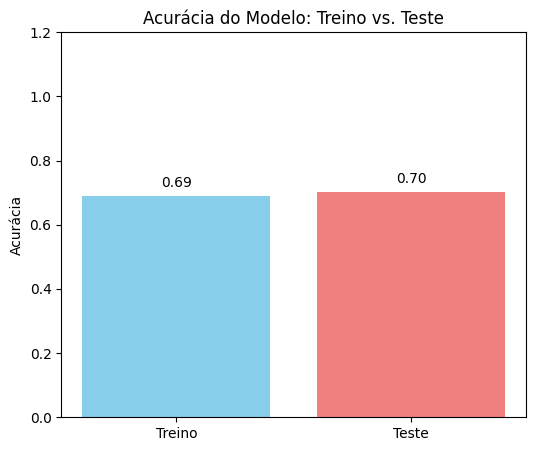

In [144]:
# ==========================================
# VERIFICAÇÃO DE OVERFITTING (TREINO vs TESTE)
# ==========================================
y_pred_train = modelo_vf.predict(X_train_c)
y_pred_test = modelo_vf.predict(X_test_c)

acc_train = accuracy_score(y_train_c, y_pred_train)
acc_test = accuracy_score(y_test_c, y_pred_test)

print("\n--- ANÁLISE DE OVERFITTING ---")
print(f"Acurácia no TREINO: {(acc_train*100):.1f}%")
print(f"Acurácia no TESTE: {(acc_test*100):.1f}%")

diferenca = acc_train - acc_test
if diferenca > 0.10:
    print(f"⚠️ ALERTA: Diferença de {diferenca*100:.1f}%. Possível Overfitting!")
else:
    print(f"✅ EXCELENTE: Diferença de {diferenca*100:.1f}%. O modelo generaliza bem!")

    # --- GRAFICO DE ACURACIA DO MODELO ---

# Cria um DataFrame para facilitar a plotagem da acuracia
accuracy_data = pd.DataFrame({
    'Conjunto': ['Treino', 'Teste'],
    'Acuracia': [acc_train, acc_test]
})

# Cria o gráfico de barras
plt.figure(figsize=(6, 5)) # Define o tamanho da figura
plt.bar(accuracy_data['Conjunto'], accuracy_data['Acuracia'], color=['skyblue', 'lightcoral'])

# # Define o limite do eixo Y de 0 a 1, já que é uma acurácia
plt.ylim(0, 1.2)

# Adiciona rótulos e título
plt.ylabel('Acurácia')
plt.title('Acurácia do Modelo: Treino vs. Teste')

# # Adiciona uma grade no eixo Y para melhor leitura
# plt.grid(axis='y', linestyle='--')

# Adiciona os valores de acurácia no topo das barras
for index, value in enumerate(accuracy_data['Acuracia']):
    plt.text(index, value + 0.02, f'{value:.2f}', ha='center', va='bottom')


plt.show()


--- MATRIZ DE CONFUSÃO


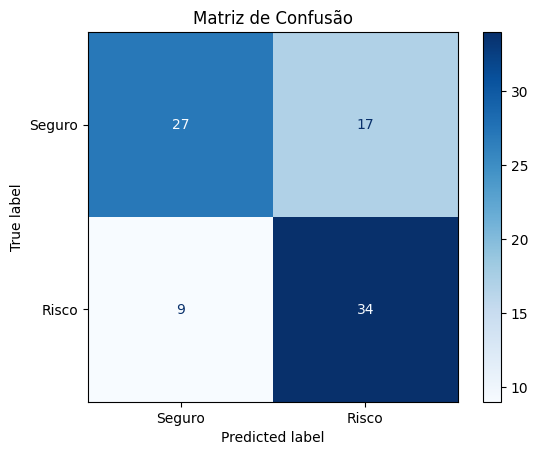

In [145]:
print("\n--- MATRIZ DE CONFUSÃO")
cm_ajustada = confusion_matrix(y_test_c, y_pred_test)

# Gráfico matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ajustada, display_labels=['Seguro', 'Risco'])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Matriz de Confusão')
plt.show()

### SALVANDO MODELO E BASE PARA STREAMLIT

In [146]:
# SALVANDO O MODELO
joblib.dump(modelo_vf, 'modelo_passos_magicos_vf.pkl')

print("✅ Modelo salvo com sucesso! O arquivo 'modelo_passos_magicos_vf.pkl' foi criado.")

✅ Modelo salvo com sucesso! O arquivo 'modelo_passos_magicos_vf.pkl' foi criado.


In [147]:
# RESGATANDO OS NOMES DOS ALUNOS PARA O STREAMLIT

# Remove duplicados
df_nomes = df_base2_temp[['RA', 'Nome']].drop_duplicates()

# "PROCV" com a base final
df_treino_base2 = pd.merge(df_treino_base2, df_nomes, on='RA', how='left')

# validação
print(df_treino_base2[['RA', 'Nome']].head())


       RA       Nome
0  RA-103  Aluno-103
1  RA-106  Aluno-106
2  RA-107  Aluno-107
3  RA-110  Aluno-110
4  RA-111  Aluno-111


In [148]:
df_treino_base2.head()

,RA,Defasagem_2022,Defasagem_2023,Defasagem_2024,IAA_2022,IAA_2023,IAA_2024,IDA_2022,IDA_2023,IDA_2024,...,IPP_2023,IPP_2024,IPS_2022,IPS_2023,IPS_2024,IPV_2022,IPV_2023,IPV_2024,TARGET,Nome
0,RA-103,1.0,1.0,0.0,7.9,8.3,8.334,7.3,7.1,9.166667,...,8.12500,7.8750,7.5,5.0,6.260,7.708,8.0900,8.872,1,Aluno-103
1,RA-106,-1.0,0.0,0.0,9.2,7.9,9.168,7.4,7.3,5.666667,...,7.03125,7.8125,9.4,5.0,5.635,8.375,7.5075,7.872,1,Aluno-106
2,RA-107,-1.0,0.0,-1.0,7.5,0.0,7.500,4.6,7.0,4.666667,...,7.34375,7.5000,7.5,5.0,7.510,6.500,7.5875,6.964,1,Aluno-107
3,RA-110,0.0,0.0,0.0,9.2,8.3,9.168,6.7,7.5,8.500000,...,8.75000,7.5000,5.6,5.0,6.255,8.000,8.2975,8.504,0,Aluno-110
4,RA-111,1.0,1.0,0.0,7.5,7.5,9.168,8.0,6.0,8.333333,...,7.65625,8.1250,8.1,5.0,6.260,8.667,8.0875,8.740,1,Aluno-111


In [149]:
# 4. Exportamos o CSV atualizado, agora com os nomes!
df_treino_base2.to_csv('dados_alunos_passos_magicos.csv', index=False)

print("\n✅ Base exportada com sucesso contendo RA e Nome!")


✅ Base exportada com sucesso contendo RA e Nome!
